# Section 1: Dataset Overview of Valorant Esports Top Earnings

Why I Chose This Dataset
I chose the Valorant Esports Top Earnings dataset because I’m a fan of the game and deeply interested in the world of competitive gaming. Esports is a fast-growing industry, and analyzing the earnings and team performance in a game like Valorant offers insights into what drives success in the scene.

This dataset is meaningful to me because it combines two things I’m passionate about: gaming and data science. I wanted to explore how player and team earnings vary, which regions dominate the scene, and what patterns can be identified in top-tier performance.

How I Found It
I searched on Kaggle for datasets related to Valorant and esports, filtering by relevance and popularity. This dataset stood out due to its clear structure and up-to-date information.

What I Want to Discover
Using this dataset, I want to answer questions like:

- Which players and teams have earned the most prize money?

- Is there a correlation between team earnings and the number of tournaments played?

- How does region impact success and earnings in Valorant esports?

- Are there standout players that consistently outperform their peers?

By applying data science techniques, I hope to visualize these trends and better understand what contributes to high performance in competitive Valorant.

In [237]:
import pandas as pd

# Load the dataset
players_df = pd.read_csv("Players.csv")
teams_df = pd.read_csv("Teams.csv")


In [238]:
# Show basic characteristics of the datasets
players_df.info()
players_df.head()

teams_df.info()
teams_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Rank      500 non-null    int64 
 1   Player    500 non-null    object
 2   Gold      500 non-null    int64 
 3   Silver    500 non-null    int64 
 4   Bronze    500 non-null    int64 
 5   S Tier    500 non-null    int64 
 6   Earnings  500 non-null    object
dtypes: int64(5), object(2)
memory usage: 27.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Rank      402 non-null    int64 
 1   Team      402 non-null    object
 2   Gold      402 non-null    int64 
 3   Silver    402 non-null    int64 
 4   Bronze    402 non-null    int64 
 5   S Tier    402 non-null    int64 
 6   Earnings  402 non-null    object
dtypes: int64(5), object(2)
memory usage: 22.1+ KB


,Rank,Team,Gold,Silver,Bronze,S Tier,Earnings
0,1,Sentinels,12,3,1,1,"$561,500"
1,2,Acend,5,1,1,1,"$498,859"
2,3,Gambit Esports,8,3,0,1,"$495,638"
3,4,Team Liquid,4,2,2,0,"$295,374"
4,5,G2 Esports,7,2,1,0,"$257,925"


In [239]:
# Columns counts
players_columns = pd.DataFrame({"Players columns": [len(players_df.columns)]})
players_columns

,Players columns
0,7


In [240]:
# Columns counts
teams_columns = pd.DataFrame({"Teams columns": [len(teams_df.columns)]})
teams_columns

,Teams columns
0,7


In [241]:
# Row counts
player_rows = pd.DataFrame({"Players rows": [len(players_df)]})
player_rows

,Players rows
0,500


In [242]:
# Row counts
teams_rows = pd.DataFrame({"Teams rows": [len(teams_df)]})
teams_rows

,Teams rows
0,402


In [243]:

# Column names
players_df.columns
teams_df.columns

Index(['Rank', 'Team', 'Gold', 'Silver', 'Bronze', 'S Tier', 'Earnings'], dtype='object')

# Section 2: Descriptive Statistics for Exploratory Data Analysis

To gain a broad understanding of the Valorant Esports Top Earnings dataset, we can use the following descriptive statistics:

Measures of Center
- Mean: Average earnings or placements give us an idea of typical performance.
- Median: Helps understand the midpoint.

Measures of Spread
- Minimum and Maximum: Shows the range of lowest and highest earnings.

Size of Dataset
- Size: Number of rows and columns tells us how much data we are working with.

Other Interesting Descriptive Statistics
- Top Players/Teams: We can identify standout individuals or organizations.

In [244]:
# Top 10 earning players
players_df["Earnings"] = players_df["Earnings"].replace(r"[\$,]", "", regex=True).astype(float)
top_5_players = players_df.nlargest(10, "Earnings")
top_5_players

,Rank,Player,Gold,Silver,Bronze,S Tier,Earnings
0,1,zombs,13,5,1,1,113550.0
1,2,ShahZaM,13,4,1,1,113450.0
2,3,dapr,14,3,1,1,112870.0
3,4,SicK,12,3,1,1,112650.0
4,5,cNed,12,4,2,1,107735.0
5,6,starxo,12,4,1,1,104394.0
6,7,Kiles,6,4,2,1,104093.0
7,8,nAts,14,6,0,1,103829.0
8,9,Chronicle,13,6,0,1,103574.0
9,10,d3ffo,12,4,2,1,102773.0


In [245]:
# Last 10 earning players
players_df["Earnings"] = players_df["Earnings"].replace(r"[\$,]", "", regex=True).astype(float)
last_5_players = players_df.nsmallest(10, "Earnings")
last_5_players

,Rank,Player,Gold,Silver,Bronze,S Tier,Earnings
499,500,Harmful,6,4,2,0,5530.0
498,499,chase,19,10,2,0,5531.0
497,498,Senhoachic,7,2,5,0,5537.0
496,497,Less,3,1,1,0,5543.0
495,496,Kim,3,4,1,0,5555.0
493,494,Shin,3,4,1,0,5578.0
494,494,Goaster,3,4,1,0,5578.0
492,493,Jerk,9,10,4,0,5585.0
491,492,Hate,4,3,0,0,5592.0
490,491,mada,2,1,0,0,5600.0


In [246]:

# Top 10 earning teams
teams_df["Earnings"] = teams_df["Earnings"].replace(r"[\$,]", "", regex=True).astype(float)
top_5_teams = teams_df.nlargest(10, "Earnings")
top_5_teams

,Rank,Team,Gold,Silver,Bronze,S Tier,Earnings
0,1,Sentinels,12,3,1,1,561500.0
1,2,Acend,5,1,1,1,498859.0
2,3,Gambit Esports,8,3,0,1,495638.0
3,4,Team Liquid,4,2,2,0,295374.0
4,5,G2 Esports,7,2,1,0,257925.0
5,6,Team Envy,2,2,2,0,251500.0
6,7,100 Thieves,2,3,2,0,225000.0
7,8,Vision Strikers,17,0,0,0,224149.0
8,9,Fnatic,1,2,2,0,210888.0
9,10,KRÜ Esports,7,3,1,0,191000.0


In [247]:
# Last 10 earning teams
teams_df["Earnings"] = teams_df["Earnings"].replace(r"[\$,]", "", regex=True).astype(float)
last_5_teams = teams_df.nsmallest(10, "Earnings")
last_5_teams

,Rank,Team,Gold,Silver,Bronze,S Tier,Earnings
401,402,Lunatic-hai FLUX,0,1,0,0,92.0
400,401,DETONA Gaming,1,0,0,0,107.0
399,400,Lunatic-hai,0,0,1,0,247.0
398,399,Nora-Rengo,1,0,0,0,267.0
397,398,Unicorns of Love,0,0,0,0,282.0
396,397,Black Dragons,0,0,0,0,283.0
395,396,SKADE,0,0,0,0,298.0
394,395,eRa Eternity,4,0,0,0,348.0
393,394,FURY,0,0,0,0,363.0
391,392,Team Empire,1,0,0,0,500.0


Descriptive Statistics Across All Teams
- Most teams win around 2–3 medals total.
- S Tier participation is rare, with only a few teams having it (max is 1).
- A small number of teams have won 7+ medals, making them major outliers.

Top 10 earning Teams
- Sentinels leads by a significant margin, over $561K, with 12 gold medals and S Tier participation.
- The next two teams are also S Tier contenders, but with fewer podium finishes.
- Team Liquid and G2 Esports remain top earners without S Tier participation, likely due to volume or regional wins.

Top 10 earning Players
- The top 4 players are likely all from Sentinels, which explains their nearly identical medal and earnings totals.
- Their earnings are within $1,000 of each other, reflecting equal distribution within the team.
- cNed breaks the pattern as the only player in the top 5 not from Sentinels, proving standout individual performance from another region.

# Section 3: Exploratory Data Visualization

In [248]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Top 10 Valorant Players by Earnings'}, xlabel='Player', ylabel='Earnings ($)'>

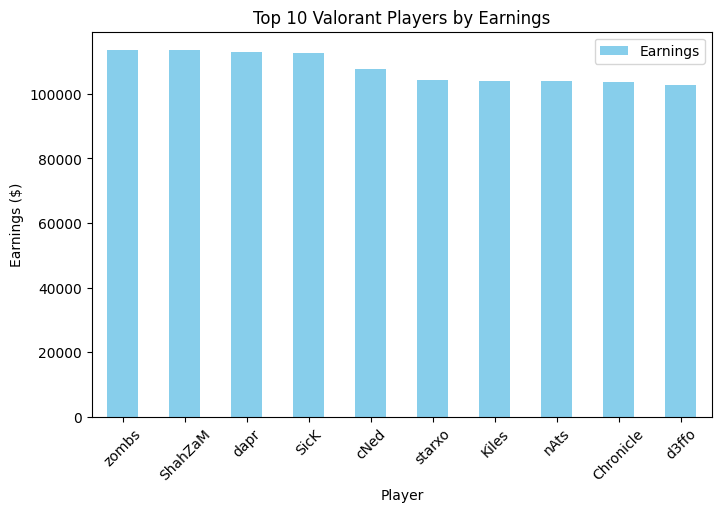

In [249]:
players_graph = players_df.nlargest(10, "Earnings")

players_graph.plot.bar(x="Player", y="Earnings", 
    title="Top 10 Valorant Players by Earnings", xlabel="Player", ylabel="Earnings ($)", 
    figsize=(8, 5), color="skyblue", rot=45)

<Axes: title={'center': 'Top 10 Valorant Teams by Earnings'}, xlabel='Team', ylabel='Earnings ($)'>

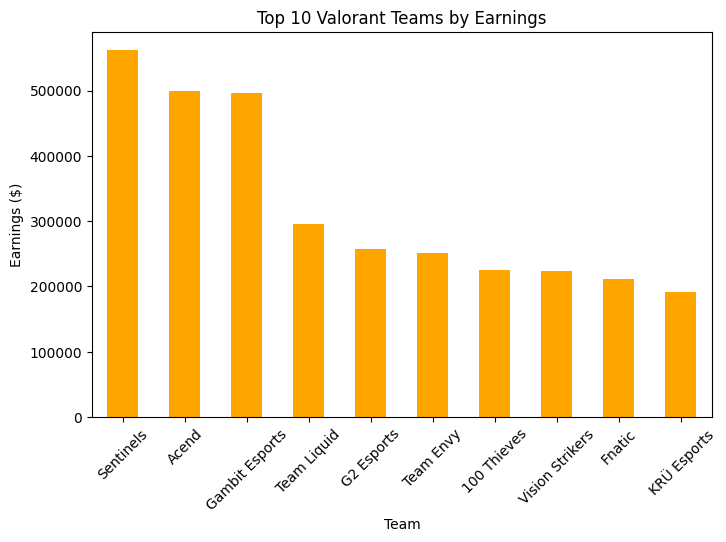

In [250]:
teams_graph = teams_df.nlargest(10, "Earnings")

teams_graph.plot.bar(x="Team", y="Earnings", legend=False, 
    title="Top 10 Valorant Teams by Earnings", xlabel="Team", ylabel="Earnings ($)", 
    figsize=(8, 5), color="orange", rot=45)

Top 10 Players by Earnings
- The graph shows that zombs, ShahZaM, dapr, and SicK top the list with nearly identical earnings, all above $112,000.
- These players likely belong to the same high-performing team, suggesting equal prize distribution and consistent team success.
- The earnings gradually decline from the 5th to 10th position, but all top 10 players earned over $80,000, indicating they were major contributors in high-stakes tournaments.
- Most of the top players competed in S Tier events, which heavily influences total earnings.

Top 10 Teams by Earnings
- Sentinels leads all teams by a wide margin with over $561,000, clearly dominating the Valorant esports scene.
- The top 3 teams are Sentinels, Acend, and Gambit Esports, they all earned near or above $495,000, reinforcing their elite status.
- There’s a noticeable earnings drop after the top few teams, showing a steep competitive gap between elite and mid-tier teams.
- The data suggests that winning S Tier events and maintaining consistent performance across tournaments is key to maximizing earnings.

Overall Insight
- Earnings are highly concentrated among a small group of top-performing teams and players.
- Team success strongly correlates with individual player earnings, especially when the team performs consistently in high-level events.
- The gap between the top and the rest underscores the competitive imbalance in professional Valorant, where a few dominant teams and players control most of the prize money.

# Section 4: Planning for Part 2

Observations from Exploratory Data Analysis
- Earnings are concentrated among a small group of top players and teams.
- The top 4 players have nearly identical earnings and likely belong to the same team.
- S Tier event participation strongly correlates with higher earnings.
- Medal counts (especially gold) are consistent among top performers.
- There’s a large earnings gap between the top and median performers, showing a competitive imbalance.

Questions I Want to Explore in Part II

1. What are the performance predictors of high earnings?
- - I plan to investigate whether gold/silver/bronze medal counts or S Tier participation are statistically significant predictors of a player’s or team’s earnings.
2. Is there a measurable earnings gap between regions?
- - I want to explore whether certain regions dominate Valorant earnings, and if so, how large the disparity is across continents or countries.
3. How much does S Tier participation affect success?
- - While it appears important, I would like to quantify how earnings differ between teams that have participated in S Tier events vs. those that haven’t.
4. Do players with more tournaments perform better overall?
- - This analysis would help understand if sustained participation correlates with competitive success or whether performance is more concentrated within a few key events.

# Section 5: Data Science

## Predicting Team Earnings Based on Medal Counts

**Question:** Can we predict a team's total earnings using their Gold, Silver, Bronze, and S Tier wins?

**Why this question?** From earlier analysis, we observed that medals and S Tier wins seem to correlate with team success. Now, we will use **linear regression** to build a model and quantify this relationship.

**Approach:**
- Convert the `Earnings` column to numeric values.
- Use `Gold`, `Silver`, `Bronze`, and `S Tier` as independent variables.
- Use `Earnings` as the dependent variable.
- Evaluate model performance using R² score.


In [251]:
import pandas as pd
from sklearn.linear_model import LinearRegression

teams_df = pd.read_csv("Teams.csv")
teams_df["Earnings"] = teams_df["Earnings"].replace(r"[\$,]", "", regex=True).astype(float)

ind = teams_df[["Gold", "Silver", "Bronze", "S Tier"]]
dep = teams_df["Earnings"]

model = LinearRegression()
model.fit(ind, dep)

teams_df["Predicted Earnings"] = model.predict(ind)

teams_df

,Rank,Team,Gold,Silver,Bronze,S Tier,Earnings,Predicted Earnings
0,1,Sentinels,12,3,1,1,561500.0,533213.109056
1,2,Acend,5,1,1,1,498859.0,508503.087553
2,3,Gambit Esports,8,3,0,1,495638.0,514280.803391
3,4,Team Liquid,4,2,2,0,295374.0,30476.693635
4,5,G2 Esports,7,2,1,0,257925.0,38569.965846
...,...,...,...,...,...,...,...,...
397,398,Unicorns of Love,0,0,0,0,282.0,10370.826035
398,399,Nora-Rengo,1,0,0,0,267.0,14231.622875
399,400,Lunatic-hai,0,0,1,0,247.0,13859.944343
400,401,DETONA Gaming,1,0,0,0,107.0,14231.622875


# Section 6: A Different Data Visualization

## Scatter Plot: Team Earnings vs. Gold Medals

This scatter plot shows the relationship between a team's total number of Gold medals and their overall earnings. It helps us understand whether teams that win more tend to earn more prize money.


<Axes: title={'center': 'Team Earnings vs. Gold Medals'}, xlabel='Number of Gold Medals', ylabel='Earnings ($)'>

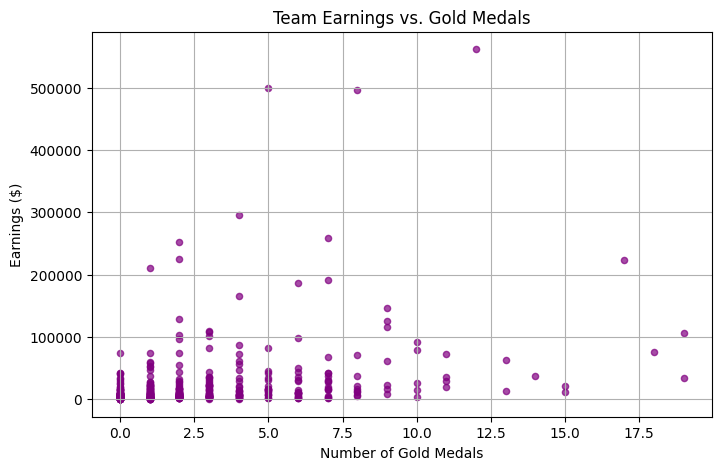

In [252]:
teams_df.plot.scatter(
    x="Gold",
    y="Earnings",
    title="Team Earnings vs. Gold Medals",
    xlabel="Number of Gold Medals",
    ylabel="Earnings ($)",
    color="purple",
    figsize=(8, 5),
    alpha=0.7,
    grid=True
)

# Section 7: Overall Summary


**Summary of Visualization:**  
This scatter plot shows a general positive trend between the number of Gold medals and total team earnings. While most teams with 0–3 Gold medals have lower earnings, a few outliers with relatively few Golds still earn significantly more, possibly due to success in high-stakes tournaments or S Tier wins. The spread also suggests that earning potential is influenced by more than just medal count.

In this project, I explored a dataset of top Valorant esports teams and players, focusing on tournament results and earnings. The highest-earning team was Sentinels with $561,500, followed by Acend and Gambit Esports. Most teams earned between $50,000 and $300,000, with big gaps between the top performers and the rest.

I used linear regression to predict team earnings based on Gold, Silver, Bronze, and S Tier wins. The model added a "Predicted Earnings" column to the dataset, helping quantify how medal counts relate to earnings. This kind of modeling could help tournament analysts or teams estimate expected performance value.

Two key visualizations supported the findings. A bar chart highlighted the top 10 teams by earnings, and a scatter plot showed that Gold medal count has a moderate positive relationship with earnings. However, variation in the data suggests that other factors also influence financial success.

This project helped me practice real-world data science skills like cleaning, modeling, and visualization. It also gave insights into what might drive success in competitive Valorant, not just winning, but winning at the right level.
